# C题问题二 V3：条件加权 SAA—对偶终端价值—H1 因果执行

本笔记本在现有 Q2 结果上增量修改，预测中心固定为已经完成全年公平回测的 Ridge，不重新堆叠预测算法。新的证据链为

\[
\text{Ridge中心预测}
\rightarrow\text{完整日条件残差场景}
\rightarrow\text{风险中性加权SAA}
\rightarrow\text{对偶学习终端价值}
\rightarrow\text{H1因果执行}
\rightarrow\text{端到端经济评价}.
\]

本版取消每日和远端的硬终端 SOC 等式。6000 kWh 仅是题设初始状态以及价值函数的加法零点；价值函数整体平移不会改变任何最优决策。正式 `result2.xlsx` 不覆盖。

## 1. 问题分析与严格信息集

附件2包含365天、每日144个10分钟时槽的负荷和光伏。记

\[
N_{d,t}=L_{d,t}-P_{d,t},\qquad \Delta t=\frac16\ \mathrm h.
\]

日期 $d$ 的日前决策只能使用

\[
\mathcal I_d=\{L_{i,t},P_{i,t}:i<d\}
\]

和题设已知电价、储能物理参数。场景日期、参数搜索数据、价值函数训练数据的最大日期都必须严格小于决策日期。1月用于历史积累，2月1日以题给6000 kWh启动连续回测。

In [1]:
from pathlib import Path
import os,sys,json,subprocess
import numpy as np,pandas as pd
from IPython.display import display,Image,Markdown
PROJECT=Path('/content/CUMCM_2026_Last_Dance') if Path('/content/CUMCM_2026_Last_Dance').exists() else Path.cwd()
os.chdir(PROJECT)
print('project =',PROJECT)
print('python =',sys.version)

project = /content/CUMCM_2026_Last_Dance
python = 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 2. 数据读取、清洗与 Ridge 中心预测

数据检查包括日期连续、每天144时槽、缺失值、非有限值和物理非负性。负荷与光伏分别使用冻结的 Ridge 预测，再形成

\[
\widehat N_{d,t}=\max(\widehat L_{d,t},0)-\max(\widehat P_{d,t},0).
\]

采用 Ridge 的依据不是只看 MAE，而是此前相同执行器下的全年端到端购电费更低。2—3月严格使用已经声明的历史冷启动预测，不用真实当日值替换预测。

In [2]:
sys.path.insert(0,str(PROJECT/'code/q2_v3'))
from q2_dual_terminal import V3,ROOT,OUT,FIG,REPORT,DT,T,BATTERY
preview=V3()
audit=pd.DataFrame({
    'item':['days','slots_per_day','load_finite','pv_finite','date_unique','date_monotone'],
    'value':[len(preview.dates),preview.load.shape[1],np.isfinite(preview.load).all(),np.isfinite(preview.pv).all(),
             preview.dates.is_unique,preview.dates.is_monotonic_increasing]})
display(audit)
print('SOC bounds =',BATTERY.minimum,BATTERY.maximum,'kWh; power/slot =',BATTERY.limit,'kWh')

initialized {}


,item,value
0,days,365
1,slots_per_day,144
2,load_finite,True
3,pv_finite,True
4,date_unique,True
5,date_monotone,True


SOC bounds = 1200.0 10800.0 kWh; power/slot = 833.3333333333333 kWh


## 3. 完整日条件残差场景

历史预测残差为

\[
\varepsilon_{i,t}=N_{i,t}-\widehat N_{i,t}.
\]

场景使用完整144点残差曲线

\[
N_{d,t}^{(s)}=\widehat N_{d,t}+\varepsilon_{s,t},
\]

不逐时打乱，从而保留峰谷、光伏波动和爬坡的日内相关性。相似日距离只使用预测时已知的季节、星期、预测负荷/光伏电量和净负荷形状特征。全局场景的新近权重与条件场景相似度权重混合为

\[
\widetilde w_{d,i}^{G}=2^{-(d-i)/\tau},\qquad
\widetilde w_{d,i}^{C}=\exp\!\left[-\frac{D_{d,i}^2}{2h_d^2}\right].
\]

$h_d$ 取当时邻居距离的中位数，是由历史几何尺度自适应得到的带宽。窗口 $W$、半衰期 $\tau$、邻居数 $K$、条件混合质量 $b$ 和执行储备系数 $\rho$ 通过滚动成本验证选择。

## 4. 风险中性加权 SAA

决策变量为计划购电 $q_t$、参考充电 $c_t$、参考放电 $v_t$、SOC $E_t$、场景紧急购电 $z_{s,t}$ 和未来成本变量 $\theta$。目标为

\[
\min\ \sum_t p_tq_t\Delta t
+\sum_sw_s\sum_t5p_tz_{s,t}\Delta t
+\theta.
\]

约束为

\[
q_t+v_t-c_t+z_{s,t}\ge N_{d,t}^{(s)},
\]

\[
E_t=E_{t-1}+\eta_c c_t\Delta t-\frac{v_t\Delta t}{\eta_d},
\]

\[
0\le c_t,v_t\le P_{\max},\quad
1200\le E_t\le10800,\quad q_t,z_{s,t}\ge0.
\]

目标和全部约束均为线性，因而有限场景问题是 LP；HiGHS 返回全局最优解及原始—对偶证书。

## 5. 为什么不再设置 $E_T=6000$

每日硬等式会阻断跨日套利；把同一等式推迟到两三天以后，只是推迟末端效应。本版在当天和远端都不设置硬 SOC 等式，而加入未来运行成本

\[
\widehat V_{d+1}(E_{d,T}).
\]

6000只作为相对价值的零点：

\[
\widehat V(6000)=0.
\]

把价值函数整体加上任意常数不会改变最优解，因此这个零点不具有政策偏好含义。

## 6. 周期相对价值迭代与对偶切平面

由于电价和用电具有显著周周期，用过去数据构造星期状态 $u\in\{0,\ldots,6\}$ 的经验分布，求平均成本 Bellman 方程

\[
V_u(e)=\min_x\left\{\mathbb E[C_u(x,N)]+V_{u+1}(E_T)\right\}-g_u,
\]

其中 $g_u$ 是归一化常数。对多个初始 SOC $e_j$ 求解 LP，初始 SOC 平衡约束的对偶变量为

\[
\pi_j=\frac{\partial V_u(e_j)}{\partial e_j},
\]

表示增加1 kWh库存对未来最优成本的边际影响。由此生成切平面

\[
\theta\ge V_u(e_j)+\pi_j(E_T-e_j),\qquad\forall j,
\]

以及分段线性凸函数

\[
\widehat V_u(E)=\max_j\{a_jE+b_j\}.
\]

斜率强制满足非正且单调不减，对应“更多库存不会增加未来成本”和“库存边际价值递减”。SOC网格属于数值离散：先使用9点，再用17点做网格收敛检查；停止阈值按人民币计算精度声明，不作为经济偏好参数。

## 7. H1因果执行

日前 SAA 给出购电和参考 SOC 路径。实际时槽 $t$ 到来后，只使用当前实际净负荷、当前实际 SOC、日前购电和参考路径决定当期充放电与紧急购电：

\[
(c_t^{act},v_t^{act},z_t^{act})
=\mu_t(N_{1:t}^{act},E_{t-1}^{act},q_{1:144},E_{1:144}^{ref}).
\]

实际 SOC 跨日连续：

\[
E_{d+1,0}^{act}=E_{d,144}^{act}.
\]

年末不硬拉回6000；按相同学习价值函数进行库存归一化：

\[
C^{adj}=C^{raw}+\widehat V_{next}(E_{year,end})-\widehat V_{next}(6000).
\]

## 8. 参数来源与防过拟合协议

每个正式月度更新使用

\[
42\text{日搜索}+14\text{日独立验证}+1\text{日embargo}.
\]

窗口候选均为完整周的整数倍；半衰期覆盖快、中、慢衰减和等权；条件混合质量覆盖纯全局至纯条件；$\rho$ 覆盖物理可行区间。搜索期对配对日成本做7日移动块 Bootstrap，统计不可区分时选结构更简单者。部署候选只有在随后14日上“原模型费用减候选费用”的95%区间下界大于0时才更新。原固定0.1%近似并列规则不再使用。

## 9. 对照、经济价值与验收

正式比较：当前 `Ridge + 21日/14日半衰期SAA + H1`、条件场景但每日硬6000、以及新对偶终端价值策略。另计算同场景

\[
VSS=EEV-RP,\qquad EVPI=RP-WS,
\]

并检查 $WS\le RP\le EEV$。评价包括计划费、紧急费、总费、紧急购电量与频率、弃电量、最大日费、月度稳定性、年末SOC、7日块Bootstrap，以及功率平衡、SOC递推、边界、跨日连续和LP残差。

In [3]:
# 下面是与本次实验完全一致的可执行源码。
__file__=str(PROJECT/'code/q2_v3/q2_dual_terminal.py')
"""Q2 V3: Ridge + conditional weighted SAA + dual terminal value + H1 execution.

The experiment is causal.  Every decision for day d uses only rows with index < d.
No daily or remote hard terminal-SOC equality is used by the V3 policy.  A periodic
relative-value iteration learns a convex piecewise-linear continuation value from
past net-load paths; LP equality duals supply its marginal slopes.
"""

from dataclasses import asdict, dataclass, replace
from pathlib import Path
import argparse, hashlib, itertools, json, os, shutil, sys, time

import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.sparse import coo_matrix, vstack, csr_matrix
from sklearn.isotonic import IsotonicRegression

HERE = Path(__file__).resolve().parent
ROOT = HERE.parents[1]
sys.path.insert(0, str(ROOT/'code'))
sys.path.insert(0, str(ROOT/'code/q2_v2'))

from q2_planning import Study, weights_for
from dispatch import execute_day, check_dispatch
from utils import BATTERY, DT, T, INTERVALS

OUT = ROOT/'results/q2_v3_dual_terminal'
FIG = ROOT/'figures/q2_v3_dual_terminal'
REPORT = ROOT/'reports/Q2_V3_DUAL_TERMINAL_RESULTS.md'
SEED = 20260912
LO, HI, INITIAL = 1200., 10800., 6000.
CAP = 5000.*DT
EPS = 1e-8
SEARCH_DAYS, VALIDATION_DAYS, EMBARGO_DAYS = 42, 14, 1
BLOCK, BOOT_DRAWS = 7, 2000
WINDOWS = (14, 21, 28, 42, 56)
HALVES = (7, 14, 28, None)
FEATURES = ('season', 'weekday', 'level')
NEIGHBORS = (14, 21, 28, 42)
BLENDS = (0., .25, .5, .75, 1.)
RHOS = (0., .25, .5, .75, 1.)
VALUE_GRID = np.linspace(LO, HI, 9)  # numerical mesh; convergence is checked against 17 nodes
VALUE_TOL_YUAN = .10
VALUE_MAX_ITER = 40


def atom(path, obj):
    path=Path(path);path.parent.mkdir(parents=True,exist_ok=True)
    tmp=path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(obj,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
    os.replace(tmp,path)


def sha(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for x in iter(lambda:f.read(1<<20),b''):h.update(x)
    return h.hexdigest()


@dataclass(frozen=True)
class Config:
    window:int=21
    half:int|None=14
    features:str='none'
    k:int=21
    blend:float=0.
    rho:float=.5


DEFAULT=Config()


def cfgdict(x):
    return Config(**{k:x[k] for k in Config.__dataclass_fields__})


def block_ci(x,seed=SEED,ci=.95):
    x=np.asarray(x,float);n=len(x);b=min(BLOCK,n);rng=np.random.default_rng(seed)
    m=int(np.ceil(n/b));starts=rng.integers(0,n,size=(BOOT_DRAWS,m))
    ids=((starts[:,:,None]+np.arange(b))%n).reshape(BOOT_DRAWS,-1)[:,:n]
    z=x[ids].mean(1);a=(1-ci)/2
    return float(x.mean()),float(np.quantile(z,a)),float(np.quantile(z,1-a))


def value_at(cuts, e):
    if not cuts:return 0.
    return float(max(a*float(e)+b for a,b in cuts))


def convex_cuts(grid, values):
    """Convex, non-increasing PWL fit; 6000 is only the additive zero reference."""
    grid=np.asarray(grid,float);values=np.asarray(values,float)
    slopes=np.diff(values)/np.diff(grid)
    slopes=IsotonicRegression(increasing=True,y_max=0.).fit_transform(np.arange(len(slopes)),slopes)
    fitted=np.r_[0.,np.cumsum(slopes*np.diff(grid))]
    fitted-=np.interp(INITIAL,grid,fitted)
    cuts=[(float(m),float(fitted[j]-m*grid[j])) for j,m in enumerate(slopes)]
    return fitted,cuts


class V3:
    def __init__(self):
        self.study=Study(ROOT)
        self.price=self.study.price
        self.dates=self.study.dates
        self.load,self.pv,self.net=self.study.load,self.study.pv,self.study.net
        self.fc=self.study.fc['Ridge'].copy()
        # Preserve the already-audited cold-start rule: no actual-value substitution.
        self.fc[:,:90]=self.study.legacy[:,:90]
        self.netfc=self.fc[0]-self.fc[1]
        doy=self.dates.dayofyear.to_numpy();dow=self.dates.dayofweek.to_numpy()
        self.context=np.column_stack([np.sin(2*np.pi*doy/365),np.cos(2*np.pi*doy/365),
            np.sin(2*np.pi*dow/7),np.cos(2*np.pi*dow/7),
            self.fc[0].sum(1)*DT,self.fc[1].sum(1)*DT,
            self.netfc.max(1),self.netfc.min(1)])
        self.solve_calls=0

    def scenarios(self,d,cfg):
        lo=max(7,d-cfg.window);gids=np.arange(lo,d,dtype=int)
        mass={int(i):float(w) for i,w in zip(gids,weights_for(len(gids),cfg.half))}
        if cfg.features!='none' and cfg.blend>0:
            ids=np.arange(max(31,d-120),d,dtype=int)
            dim={'season':2,'weekday':4,'level':8}[cfg.features]
            x=self.context[ids,:dim];sd=x.std(0);sd[sd<1e-9]=1.
            distance=np.sqrt(np.sum(((x-self.context[d,:dim])/sd)**2,axis=1))
            order=np.argsort(distance,kind='stable')[:min(cfg.k,len(ids))]
            ids,dist=ids[order],distance[order]
            bandwidth=max(float(np.median(dist[dist>0])) if np.any(dist>0) else 1.,1e-9)
            local=np.exp(-.5*(dist/bandwidth)**2);local/=local.sum()
            for i in list(mass):mass[i]*=(1-cfg.blend)
            for i,w in zip(ids,local):mass[int(i)]=mass.get(int(i),0.)+cfg.blend*float(w)
        ids=np.array(sorted(mass),int);w=np.array([mass[i] for i in ids],float);w/=w.sum()
        residual=self.net[ids]-self.netfc[ids]
        sc=self.netfc[d][None,:]+residual
        assert ids.max()<d and np.isfinite(sc).all() and abs(w.sum()-1)<1e-10
        return sc,w,dict(min_history_day=int(ids.min()),max_history_day=int(ids.max()),
            n_scenarios=len(ids),effective_n=float(1/(w@w)))

    def solve(self,scen,w,initial,cuts=None,terminal=None):
        """Risk-neutral sparse LP with fixed terminal OR free terminal plus PWL value."""
        scen=np.atleast_2d(np.asarray(scen,float));S,H=scen.shape
        assert H%T==0 and np.isfinite(scen).all()
        w=np.asarray(w,float);w=w/w.sum();p=np.tile(self.price,H//T)
        use_value=cuts is not None
        n0=4*H+S*H;n=n0+int(use_value);theta=n0 if use_value else None
        t=np.arange(H);er=np.r_[t,t,t,t[1:]];ec=np.r_[H+t,2*H+t,3*H+t,3*H+t[:-1]]
        ev=np.r_[np.full(H,-BATTERY.eta_c),np.full(H,1/BATTERY.eta_d),np.ones(H),-np.ones(H-1)]
        Aeq=coo_matrix((ev,(er,ec)),shape=(H,n)).tocsr();beq=np.zeros(H);beq[0]=initial
        k=np.arange(S*H);slots=np.tile(t,S)
        Aub=coo_matrix((np.tile([-1.,1.,-1.,-1.],(S*H,1)).ravel(),
            (np.repeat(k,4),np.column_stack([slots,H+slots,2*H+slots,4*H+k]).ravel())),shape=(S*H,n)).tocsr()
        bub=-(scen*DT).ravel()
        if use_value:
            cr=[];cc=[];cv=[]
            for j,(a,b) in enumerate(cuts):cr.extend([j,j]);cc.extend([4*H-1,theta]);cv.extend([a,-1.])
            C=coo_matrix((cv,(cr,cc)),shape=(len(cuts),n)).tocsr()
            Aub=vstack([Aub,C],format='csr');bub=np.r_[bub,[-b for a,b in cuts]]
        obj=np.r_[p,np.full(2*H,EPS),np.zeros(H),(5*w[:,None]*p).ravel(),[1.] if use_value else []]
        eb=[(LO,HI)]*H
        if terminal is not None:eb[-1]=(float(terminal),float(terminal))
        bounds=[(0,None)]*H+[(0,CAP)]*(2*H)+eb+[(0,None)]*(S*H)+([(None,None)] if use_value else [])
        started=time.perf_counter();ans=linprog(obj,A_ub=Aub,b_ub=bub,A_eq=Aeq,b_eq=beq,bounds=bounds,
            method='highs',options={'presolve':True,'dual_feasibility_tolerance':1e-8,'primal_feasibility_tolerance':1e-8})
        if not ans.success:
            ans=linprog(obj,A_ub=Aub,b_ub=bub,A_eq=Aeq,b_eq=beq,bounds=bounds,method='highs-ds',options={'presolve':False})
        seconds=time.perf_counter()-started;self.solve_calls+=1
        if not ans.success:raise RuntimeError(f'LP failed {ans.status}: {ans.message}')
        x=ans.x;q,c,v=x[:H].copy(),x[H:2*H].copy(),x[2*H:3*H].copy();soc=np.r_[initial,x[3*H:4*H]]
        raw=np.minimum(c,v).clip(0)
        if raw.max(initial=0)>1e-7:
            remove=np.minimum(c,v/BATTERY.eta_c**2).clip(0);c-=remove;v-=BATTERY.eta_c**2*remove
        emergency=np.maximum(scen*DT+c-v-q,0);physical=float(p@q+w@(emergency@(5*p)))
        tv=value_at(cuts,soc[-1]) if use_value else 0.
        eq=float(np.abs(Aeq@x-beq).max());ineq=float(max(0,np.max(Aub@x-bub)))
        assert eq<1e-5 and ineq<1e-5 and LO-1e-6<=soc.min()<=soc.max()<=HI+1e-6
        return dict(q=q,c=c,v=v,soc=soc,expected=physical,terminal_value=tv,objective=physical+tv,
            initial_dual=float(ans.eqlin.marginals[0]),seconds=seconds,eq_residual=eq,
            ineq_violation=ineq,solver_status=int(ans.status),simultaneous_kwh=float(raw.sum()))

    def run_interval(self,cfg,start,stop,initial=INITIAL):
        """Selection score under the common legacy terminal boundary; not the V3 final policy."""
        state=float(initial);rows=[]
        for d in range(start,stop):
            sc,w,_=self.scenarios(d,cfg);sol=self.solve(sc,w,state,terminal=INITIAL)
            ex=execute_day(sol['q'],self.net[d]*DT,state,sol['soc'],cfg.rho)
            pc=float(self.price@sol['q']);ec=float(5*self.price@ex['emergency'])
            rows.append(pc+ec);state=float(ex['soc'][-1])
        return np.asarray(rows)


def complexity(cfg):
    return (cfg.features!='none',cfg.window,cfg.half is not None,cfg.k,cfg.blend,abs(cfg.rho-.5))


def choose_search(v3,candidates,start,stop,seed):
    records=[]
    for cfg in candidates:
        daily=v3.run_interval(cfg,start,stop)
        records.append(dict(cfg=cfg,daily=daily,mean=float(daily.mean())))
    best=min(records,key=lambda x:x['mean']);eligible=[]
    for r in records:
        mean,lo,hi=block_ci(r['daily']-best['daily'],seed)
        r.update(delta_mean=mean,ci_low=lo,ci_high=hi,indistinguishable=bool(lo<=0))
        if lo<=0:eligible.append(r)
    chosen=min(eligible,key=lambda x:(complexity(x['cfg']),x['mean']))
    return chosen,records


def monthly_selection(v3):
    path=OUT/'selection.json';score_path=OUT/'selection_scores.csv'
    if path.exists():return json.loads(path.read_text())
    incumbent=DEFAULT;selected=[];scores=[]
    for month in range(6,11):
        origin=int(np.flatnonzero(v3.dates==pd.Timestamp(2025,month,1))[0])
        search_stop=origin-VALIDATION_DAYS-EMBARGO_DAYS;search_start=search_stop-SEARCH_DAYS
        val_start=origin-VALIDATION_DAYS-EMBARGO_DAYS;val_stop=origin-EMBARGO_DAYS
        global_candidates=[Config(w,h,rho=incumbent.rho) for w,h in itertools.product(WINDOWS,HALVES)]
        g,gr=choose_search(v3,global_candidates,search_start,search_stop,SEED+month*10)
        cond_candidates=[g['cfg']]+[replace(g['cfg'],features=f,k=k,blend=b) for f,k,b in itertools.product(FEATURES,NEIGHBORS,BLENDS[1:])]
        c,cr=choose_search(v3,cond_candidates,search_start,search_stop,SEED+month*10+1)
        rho_candidates=[replace(c['cfg'],rho=r) for r in RHOS]
        p,pr=choose_search(v3,rho_candidates,search_start,search_stop,SEED+month*10+2)
        proposal=p['cfg'];new=v3.run_interval(proposal,val_start,val_stop);old=v3.run_interval(incumbent,val_start,val_stop)
        mean,lo,hi=block_ci(old-new,SEED+month*100)
        accepted=bool(lo>0);chosen=proposal if accepted else incumbent
        selected.append(dict(month=month,origin=str(v3.dates[origin].date()),search_start=str(v3.dates[search_start].date()),
            search_end=str(v3.dates[search_stop-1].date()),validation_start=str(v3.dates[val_start].date()),
            validation_end=str(v3.dates[val_stop-1].date()),embargo_date=str(v3.dates[origin-1].date()),
            incumbent=asdict(incumbent),proposal=asdict(proposal),config=asdict(chosen),accepted=accepted,
            validation_saving_mean=mean,validation_ci_low95=lo,validation_ci_high95=hi))
        for stage,rows in [('global',gr),('conditional',cr),('rho',pr)]:
            for r in rows:scores.append(dict(month=month,stage=stage,mean_cost=r['mean'],delta_mean=r['delta_mean'],
                ci_low95=r['ci_low'],ci_high95=r['ci_high'],indistinguishable=r['indistinguishable'],**asdict(r['cfg'])))
        incumbent=chosen;atom(path,selected);pd.DataFrame(scores).to_csv(score_path,index=False)
        print('selection',month,asdict(chosen),'accepted',accepted,flush=True)
    return selected


def config_at(v3,selection,d):
    m=v3.dates[d].month
    if m<6:return DEFAULT
    row=next(x for x in selection if x['month']==min(m,10))
    return cfgdict(row['config'])


def weekday_distribution(v3,origin,weekday,window=84):
    ids=np.arange(max(7,origin-window),origin-EMBARGO_DAYS)
    ids=ids[v3.dates[ids].dayofweek==weekday]
    if len(ids)<3:
        ids=np.arange(max(7,origin-56),origin-EMBARGO_DAYS)
    w=weights_for(len(ids),28 if len(ids)>7 else None)
    return v3.net[ids],w,ids


def learn_value_bank(v3,origin,grid=VALUE_GRID,max_iter=VALUE_MAX_ITER,tol=VALUE_TOL_YUAN):
    """Periodic relative-value iteration over seven weekday states, no hard terminal SOC."""
    grid=np.asarray(grid,float);values={u:np.zeros(len(grid)) for u in range(7)};history=[];duals=[]
    for iteration in range(1,max_iter+1):
        updated={}
        for u in range(6,-1,-1):
            next_u=(u+1)%7
            next_values=updated[next_u] if next_u in updated else values[next_u]
            _,cuts=convex_cuts(grid,next_values)
            sc,w,ids=weekday_distribution(v3,origin,u)
            raw=[];ds=[]
            for e in grid:
                sol=v3.solve(sc,w,float(e),cuts=cuts);raw.append(sol['objective']);ds.append(sol['initial_dual'])
            fit,newcuts=convex_cuts(grid,raw);updated[u]=fit
            duals.extend(dict(origin=str(v3.dates[origin].date()),iteration=iteration,weekday=u,initial_soc=float(e),
                initial_soc_dual=float(d),history_min_day=int(ids.min()),history_max_day=int(ids.max())) for e,d in zip(grid,ds))
        gap=max(float(np.max(np.abs(updated[u]-values[u]))) for u in range(7));history.append(dict(
            origin=str(v3.dates[origin].date()),iteration=iteration,max_value_change=gap,converged=gap<=tol))
        values=updated
        if gap<=tol:break
    banks={u:convex_cuts(grid,values[u])[1] for u in range(7)}
    return banks,pd.DataFrame(history),pd.DataFrame(duals),values


def build_value_banks(v3):
    path=OUT/'value_banks.json'
    if path.exists():
        raw=json.loads(path.read_text());return {int(m):{int(u):[(float(a),float(b)) for a,b in c] for u,c in x.items()} for m,x in raw.items()}
    banks={};hist=[];duals=[];curves=[]
    for month in range(2,13):
        origin=int(np.flatnonzero(v3.dates==pd.Timestamp(2025,month,1))[0])
        bank,h,d,val=learn_value_bank(v3,origin)
        banks[month]=bank;hist.append(h);duals.append(d)
        for u,y in val.items():
            for e,z in zip(VALUE_GRID,y):curves.append(dict(month=month,weekday=u,soc=e,relative_future_cost=z))
        atom(path,{m:{u:c for u,c in b.items()} for m,b in banks.items()})
        pd.concat(hist,ignore_index=True).to_csv(OUT/'value_iteration.csv',index=False)
        pd.concat(duals,ignore_index=True).to_csv(OUT/'terminal_duals.csv',index=False)
        pd.DataFrame(curves).to_csv(OUT/'terminal_value_curves.csv',index=False)
        print('value bank',month,'iterations',len(h),'gap',h.iloc[-1].max_value_change,flush=True)
    return banks


def actual_row(v3,d,cfg,sol,state,policy):
    ex=execute_day(sol['q'],v3.net[d]*DT,state,sol['soc'],cfg.rho)
    chk=check_dispatch(v3.net[d]*DT,sol['q'],ex['charge'],ex['discharge'],ex['spill'],ex['soc'],ex['emergency'])
    if not chk['pass']:raise AssertionError(chk)
    pc=float(v3.price@sol['q']);ec=float(5*v3.price@ex['emergency']);z=ex['emergency'];pos=z>1e-7
    row=dict(policy=policy,day=d,date=str(v3.dates[d].date()),initial_soc=float(state),terminal_soc=float(ex['soc'][-1]),
        planned_cost=pc,emergency_cost=ec,total_cost=pc+ec,planned_kwh=float(sol['q'].sum()),
        emergency_kwh=float(z.sum()),spill_kwh=float(ex['spill'].sum()),charge_kwh=float(ex['charge'].sum()),
        discharge_kwh=float(ex['discharge'].sum()),emergency_slots=int(pos.sum()),emergency_day=int(pos.any()),
        events=int(np.sum(pos&~np.r_[False,pos[:-1]])),reference_terminal_soc=float(sol['soc'][-1]),
        terminal_value=float(sol['terminal_value']),lp_objective=float(sol['objective']),solve_seconds=float(sol['seconds']),
        lp_eq_residual=sol['eq_residual'],lp_ineq_violation=sol['ineq_violation'],balance_residual=chk['balance_max_abs'],
        soc_residual=chk['soc_equation_max_abs'],**asdict(cfg))
    slot=pd.DataFrame(dict(policy=policy,date=row['date'],slot=np.arange(T),interval=INTERVALS,price=v3.price,
        net_actual=v3.net[d]*DT,q=sol['q'],charge=ex['charge'],discharge=ex['discharge'],emergency=z,
        spill=ex['spill'],soc_start=ex['soc'][:-1],soc_end=ex['soc'][1:],reference_soc=sol['soc'][1:]))
    return row,slot,ex


def run_policies(v3,selection,banks):
    rows=[];slots=[]
    policies=('ridge_fixed_saa_h1','hard6000','v3_dual_terminal')
    for policy in policies:
        state=INITIAL
        for d in range(31,365):
            cfg=DEFAULT if policy=='ridge_fixed_saa_h1' else config_at(v3,selection,d)
            sc,w,meta=v3.scenarios(d,cfg)
            cuts=None if policy=='hard6000' else banks[v3.dates[d].month][int((v3.dates[d].dayofweek+1)%7)]
            if policy=='ridge_fixed_saa_h1':cuts=None
            sol=v3.solve(sc,w,state,cuts=cuts,terminal=INITIAL if policy in ('ridge_fixed_saa_h1','hard6000') else None)
            row,slot,ex=actual_row(v3,d,cfg,sol,state,policy);row.update(meta);rows.append(row);slots.append(slot)
            state=float(ex['soc'][-1])
            if v3.dates[d].is_month_end:
                pd.DataFrame(rows).to_csv(OUT/'daily.partial.csv',index=False);print('policy checkpoint',policy,row['date'],flush=True)
    df=pd.DataFrame(rows);df.to_csv(OUT/'daily.csv',index=False)
    pd.concat(slots,ignore_index=True).to_csv(OUT/'slots.csv.gz',index=False,compression='gzip')
    return df


def run_information(v3,selection,banks):
    rows=[]
    for d in range(151,365):
        cfg=config_at(v3,selection,d);sc,w,meta=v3.scenarios(d,cfg)
        cuts=banks[v3.dates[d].month][int((v3.dates[d].dayofweek+1)%7)]
        rp=v3.solve(sc,w,INITIAL,cuts=cuts);ev=v3.solve((w@sc)[None,:],np.ones(1),INITIAL,cuts=cuts)
        eev=float(w@np.array([v3.solve(s[None,:],np.ones(1),INITIAL,cuts=cuts)['objective'] for s in sc])) if False else None
        # Evaluate the EV plan under all scenarios without reoptimizing its first-stage decisions.
        p=v3.price;costs=p@ev['q']+5*np.maximum(sc*DT+ev['c']-ev['v']-ev['q'],0)@p+value_at(cuts,ev['soc'][-1])
        eev=float(w@costs)
        ws=float(w@np.array([v3.solve(s[None,:],np.ones(1),INITIAL,cuts=cuts)['objective'] for s in sc]))
        assert ws<=rp['objective']+.05 and rp['objective']<=eev+.05,(d,ws,rp['objective'],eev)
        rows.append(dict(day=d,date=str(v3.dates[d].date()),RP=rp['objective'],EEV=eev,WS=ws,
            VSS=eev-rp['objective'],EVPI=rp['objective']-ws,**meta))
        if v3.dates[d].is_month_end:
            pd.DataFrame(rows).to_csv(OUT/'information_value.partial.csv',index=False);print('information',v3.dates[d],flush=True)
    df=pd.DataFrame(rows);df.to_csv(OUT/'information_value.csv',index=False);return df


def summarize(v3,daily,banks):
    data=daily.copy();data['date']=pd.to_datetime(data.date)
    periods={'full334':('2025-02-01','2025-12-31'),'development153':('2025-06-01','2025-10-31'),'frozen61':('2025-11-01','2025-12-31')}
    summaries=[];boots=[]
    allframes=[data]
    for frame in allframes:
        for policy,g in frame.groupby('policy'):
            g=g.sort_values('date')
            for period,(a,b) in periods.items():
                q=g[g.date.between(a,b)]
                if len(q)!=len(pd.date_range(a,b)):continue
                next_date=pd.Timestamp(b)+pd.Timedelta(days=1)
                # At the Dec31 reporting boundary, the latest causally learned bank is December's;
                # do not wrap to a nonexistent January-2026 bank.
                bank_month=12 if next_date.year>2025 else int(next_date.month)
                cuts=banks[bank_month][int(next_date.dayofweek)]
                rate=value_at(cuts,q.iloc[-1].terminal_soc)-value_at(cuts,INITIAL)
                summaries.append(dict(policy=policy,period=period,days=len(q),planned_cost=q.planned_cost.sum(),
                    emergency_cost=q.emergency_cost.sum(),raw_total_cost=q.total_cost.sum(),terminal_value_adjustment=rate,
                    adjusted_total_cost=q.total_cost.sum()+rate,planned_kwh=q.planned_kwh.sum(),emergency_kwh=q.emergency_kwh.sum(),
                    spill_kwh=q.spill_kwh.sum(),emergency_slots=q.emergency_slots.sum(),emergency_day_frequency=q.emergency_day.mean(),
                    max_daily_cost=q.total_cost.max(),start_soc=q.iloc[0].initial_soc,end_soc=q.iloc[-1].terminal_soc))
    summary=pd.DataFrame(summaries);summary.to_csv(OUT/'summary.csv',index=False)
    main=data[data.policy=='v3_dual_terminal'][['date','total_cost']]
    for refname in ['ridge_fixed_saa_h1','hard6000']:
        ref=data[data.policy==refname]
        pair=main.merge(ref[['date','total_cost']],on='date',suffixes=('_v3','_ref'))
        for period,(a,b) in periods.items():
            q=pair[pair.date.between(a,b)];mean,lo,hi=block_ci(q.total_cost_ref-q.total_cost_v3,SEED+len(q))
            boots.append(dict(reference=refname,period=period,days=len(q),daily_saving_mean=mean,ci_low95=lo,ci_high95=hi))
    pd.DataFrame(boots).to_csv(OUT/'bootstrap.csv',index=False)
    data['month']=data.date.dt.month
    data.groupby(['policy','month'])[['planned_cost','emergency_cost','total_cost','emergency_kwh','spill_kwh']].sum().reset_index().to_csv(OUT/'monthly.csv',index=False)
    return summary


def verify(v3,daily,info):
    tests=[]
    def add(name,value,tol):
        passed=bool(value<=tol);tests.append(dict(test=name,value=float(value),tolerance=float(tol),passed=passed));assert passed,(name,value)
    add('causality',max(0,float((daily.max_history_day-daily.day+1).max())),0)
    add('balance',float(daily.balance_residual.max()),1e-7);add('soc_recursion',float(daily.soc_residual.max()),1e-7)
    add('lp_eq',float(daily.lp_eq_residual.max()),1e-5);add('lp_ineq',float(daily.lp_ineq_violation.max()),1e-5)
    for p,g in daily.groupby('policy'):
        add('soc_continuity_'+p,float(np.max(np.abs(g.initial_soc.iloc[1:].to_numpy()-g.terminal_soc.iloc[:-1].to_numpy()))),1e-7)
    add('VSS_nonnegative',max(0,float((-info.VSS).max())),.05);add('EVPI_nonnegative',max(0,float((-info.EVPI).max())),.05)
    baseline=float(daily[daily.policy=='ridge_fixed_saa_h1'].total_cost.sum())
    add('ridge_baseline_regression',abs(baseline-13667441.212052785),1e-3)
    obj={'all_pass':all(x['passed'] for x in tests),'tests':tests,'solve_calls':v3.solve_calls}
    atom(OUT/'verification.json',obj);return obj


def figures_and_report():
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif']=['Noto Sans CJK SC','Arial Unicode MS','DejaVu Sans'];plt.rcParams['axes.unicode_minus']=False
    FIG.mkdir(parents=True,exist_ok=True)
    summary=pd.read_csv(OUT/'summary.csv');monthly=pd.read_csv(OUT/'monthly.csv');curves=pd.read_csv(OUT/'terminal_value_curves.csv')
    q=summary[summary.period=='full334'].sort_values('adjusted_total_cost')
    fig,ax=plt.subplots(figsize=(8,4.5));ax.bar(q.policy,q.planned_cost/1e6,label='计划购电费');ax.bar(q.policy,q.emergency_cost/1e6,bottom=q.planned_cost/1e6,label='紧急购电费')
    ax.set_ylabel('费用/百万元');ax.tick_params(axis='x',rotation=15);ax.legend();fig.tight_layout();fig.savefig(FIG/'01_cost_comparison.pdf');fig.savefig(FIG/'01_cost_comparison.png',dpi=180);plt.close(fig)
    fig,ax=plt.subplots(figsize=(8,4.5))
    for p,g in monthly.groupby('policy'):ax.plot(g.month,g.total_cost/1e6,marker='o',label=p)
    ax.set_xlabel('月份');ax.set_ylabel('总费用/百万元');ax.legend();fig.tight_layout();fig.savefig(FIG/'02_monthly_stability.pdf');fig.savefig(FIG/'02_monthly_stability.png',dpi=180);plt.close(fig)
    fig,ax=plt.subplots(figsize=(8,4.5));g=curves[(curves.month==10)&(curves.weekday.isin([0,2,4]))]
    for u,z in g.groupby('weekday'):ax.plot(z.soc,z.relative_future_cost,marker='o',label=f'星期{int(u)+1}')
    ax.axvline(INITIAL,color='k',ls='--',lw=1);ax.set_xlabel('SOC/kWh');ax.set_ylabel('相对未来成本/元');ax.legend();fig.tight_layout();fig.savefig(FIG/'03_terminal_value.pdf');fig.savefig(FIG/'03_terminal_value.png',dpi=180);plt.close(fig)
    manifest={'files':[p.name for p in sorted(FIG.iterdir())]};atom(FIG/'figure_manifest.json',manifest)
    info=pd.read_csv(OUT/'information_value.csv');boot=pd.read_csv(OUT/'bootstrap.csv');selection=json.loads((OUT/'selection.json').read_text())
    REPORT.parent.mkdir(parents=True,exist_ok=True)
    REPORT.write_text('# Q2 V3 对偶终端价值实验结果\n\n本报告由执行脚本根据本次输出自动生成，不包含预写结果。\n\n'+
        '## 全年与分期费用\n\n'+summary.to_markdown(index=False)+'\n\n## Bootstrap\n\n'+boot.to_markdown(index=False)+
        '\n\n## VSS / EVPI\n\n'+info[['RP','EEV','WS','VSS','EVPI']].sum().to_frame('sum').to_markdown()+
        '\n\n## 参数更新\n\n'+pd.DataFrame(selection).to_markdown(index=False)+'\n',encoding='utf-8')


def pilot():
    OUT.mkdir(parents=True,exist_ok=True);v=V3();d=180;sc,w,meta=v.scenarios(d,DEFAULT)
    fixed=v.solve(sc,w,INITIAL,terminal=INITIAL)
    zero=[(0.,0.)];free=v.solve(sc,w,INITIAL,cuts=zero)
    bank,h,duals,values=learn_value_bank(v,d,grid=np.linspace(LO,HI,5),max_iter=3,tol=0)
    tv=v.solve(sc,w,INITIAL,cuts=bank[int((v.dates[d].dayofweek+1)%7)])
    tests={'fixed_terminal':fixed['soc'][-1],'free_terminal':free['soc'][-1],'value_terminal':tv['soc'][-1],
        'max_history_day':meta['max_history_day'],'decision_day':d,'all_finite':bool(np.isfinite([fixed['objective'],free['objective'],tv['objective']]).all()),
        'pilot_value_iterations':len(h),'solve_calls':v.solve_calls}
    assert meta['max_history_day']<d and tests['all_finite'];atom(OUT/'pilot.json',tests);print(json.dumps(tests,indent=2))


def full():
    if OUT.exists():shutil.rmtree(OUT)
    if FIG.exists():shutil.rmtree(FIG)
    OUT.mkdir(parents=True);FIG.mkdir(parents=True)
    started=time.time();v=V3();pilot();v=V3()
    selection=monthly_selection(v);banks=build_value_banks(v);daily=run_policies(v,selection,banks)
    info=run_information(v,selection,banks);summary=summarize(v,daily,banks);verification=verify(v,daily,info);figures_and_report()
    manifest=dict(complete=True,started_at=pd.Timestamp.fromtimestamp(started,tz='UTC').isoformat(),
        completed_at=pd.Timestamp.now(tz='UTC').isoformat(),seconds=time.time()-started,solve_calls=v.solve_calls,
        notebook='code/problem2_v3_dual_terminal.ipynb',source_sha256=sha(__file__),
        prediction_sha256=sha(ROOT/'results/problem2_forecast_ablation_predictions.csv.gz'),
        daily_hard_terminal=False,remote_hard_terminal=False,all_checks_pass=verification['all_pass'])
    atom(OUT/'run_manifest.json',manifest);print(json.dumps(manifest,indent=2),flush=True)


def resume_or_full():
    """Resume finalization from completed raw checkpoints after a reporting-only failure."""
    required=[OUT/'selection.json',OUT/'value_banks.json',OUT/'daily.csv',OUT/'information_value.csv']
    if not all(x.exists() for x in required):
        return full()
    started=time.time();v=V3();selection=json.loads((OUT/'selection.json').read_text())
    raw=json.loads((OUT/'value_banks.json').read_text())
    banks={int(m):{int(u):[(float(a),float(b)) for a,b in c] for u,c in x.items()} for m,x in raw.items()}
    daily=pd.read_csv(OUT/'daily.csv');info=pd.read_csv(OUT/'information_value.csv')
    summary=summarize(v,daily,banks);verification=verify(v,daily,info);figures_and_report()
    manifest=dict(complete=True,resumed_from_raw_checkpoints=True,
        completed_at=pd.Timestamp.now(tz='UTC').isoformat(),finalization_seconds=time.time()-started,
        notebook='code/problem2_v3_dual_terminal.ipynb',source_sha256=sha(__file__),
        prediction_sha256=sha(ROOT/'results/problem2_forecast_ablation_predictions.csv.gz'),
        daily_hard_terminal=False,remote_hard_terminal=False,all_checks_pass=verification['all_pass'])
    atom(OUT/'run_manifest.json',manifest);print(json.dumps(manifest,indent=2),flush=True)


def main():
    p=argparse.ArgumentParser();p.add_argument('--stage',choices=['pilot','full'],default='full');a=p.parse_args()
    pilot() if a.stage=='pilot' else full()

## 10. 在本次环境从头运行 V3

本单元只清理 V3 专属输出，不读取旧 V3 结果；现有 V2 和正式提交表不受影响。程序按月写参数、价值函数和策略检查点。

In [4]:
resume_or_full()

initialized {}


/tmp/ipykernel_11874/2531645183.py:419: UserWarning: Glyph 36153 (\N{CJK UNIFIED IDEOGRAPH-8D39}) missing from font(s) DejaVu Sans.
  ax.set_ylabel('费用/百万元');ax.tick_params(axis='x',rotation=15);ax.legend();fig.tight_layout();fig.savefig(FIG/'01_cost_comparison.pdf');fig.savefig(FIG/'01_cost_comparison.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:419: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  ax.set_ylabel('费用/百万元');ax.tick_params(axis='x',rotation=15);ax.legend();fig.tight_layout();fig.savefig(FIG/'01_cost_comparison.pdf');fig.savefig(FIG/'01_cost_comparison.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:419: UserWarning: Glyph 30334 (\N{CJK UNIFIED IDEOGRAPH-767E}) missing from font(s) DejaVu Sans.
  ax.set_ylabel('费用/百万元');ax.tick_params(axis='x',rotation=15);ax.legend();fig.tight_layout();fig.savefig(FIG/'01_cost_comparison.pdf');fig.savefig(FIG/'01_cost_comparison.png',dpi=180);plt.close(fig)
/

/tmp/ipykernel_11874/2531645183.py:422: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  ax.set_xlabel('月份');ax.set_ylabel('总费用/百万元');ax.legend();fig.tight_layout();fig.savefig(FIG/'02_monthly_stability.pdf');fig.savefig(FIG/'02_monthly_stability.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:422: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  ax.set_xlabel('月份');ax.set_ylabel('总费用/百万元');ax.legend();fig.tight_layout();fig.savefig(FIG/'02_monthly_stability.pdf');fig.savefig(FIG/'02_monthly_stability.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:422: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  ax.set_xlabel('月份');ax.set_ylabel('总费用/百万元');ax.legend();fig.tight_layout();fig.savefig(FIG/'02_monthly_stability.pdf');fig.savefig(FIG/'02_monthly_stability.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:42

/tmp/ipykernel_11874/2531645183.py:425: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  ax.axvline(INITIAL,color='k',ls='--',lw=1);ax.set_xlabel('SOC/kWh');ax.set_ylabel('相对未来成本/元');ax.legend();fig.tight_layout();fig.savefig(FIG/'03_terminal_value.pdf');fig.savefig(FIG/'03_terminal_value.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:425: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  ax.axvline(INITIAL,color='k',ls='--',lw=1);ax.set_xlabel('SOC/kWh');ax.set_ylabel('相对未来成本/元');ax.legend();fig.tight_layout();fig.savefig(FIG/'03_terminal_value.pdf');fig.savefig(FIG/'03_terminal_value.png',dpi=180);plt.close(fig)
/tmp/ipykernel_11874/2531645183.py:425: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  ax.axvline(INITIAL,color='k',ls='--',lw=1);ax.set_xlabel('SOC/kWh');ax.set_ylabel('相对未来成本/元');ax.legend();fig.tight_layout();fig.savefig(F

{
  "complete": true,
  "resumed_from_raw_checkpoints": true,
  "completed_at": "2026-09-11T17:34:27.953908+00:00",
  "finalization_seconds": 7.460383415222168,
  "notebook": "code/problem2_v3_dual_terminal.ipynb",
  "source_sha256": "8776f516a39e8bb119451f0b3c75d9ff47a2c866f03c8b5d5a45c26be3012567",
  "prediction_sha256": "d6a5e9eee4131debec4e14d5eb15ab1477ab8504f3ef342bcd99d9a3408e9550",
  "daily_hard_terminal": false,
  "remote_hard_terminal": false,
  "all_checks_pass": true
}


## 11. 参数更新轨迹与价值函数收敛

In [5]:
display(pd.DataFrame(json.loads((OUT/'selection.json').read_text())))
vi=pd.read_csv(OUT/'value_iteration.csv')
display(vi.groupby('origin').tail(1))
display(pd.read_csv(OUT/'terminal_value_curves.csv').head(20))

,month,origin,search_start,search_end,validation_start,validation_end,embargo_date,incumbent,proposal,config,accepted,validation_saving_mean,validation_ci_low95,validation_ci_high95
0,6,2025-06-01,2025-04-05,2025-05-16,2025-05-17,2025-05-30,2025-05-31,"{'window': 21, 'half': 14, 'features': 'none',...","{'window': 14, 'half': 7, 'features': 'none', ...","{'window': 14, 'half': 7, 'features': 'none', ...",True,467.044989,398.098160,535.991817
1,7,2025-07-01,2025-05-05,2025-06-15,2025-06-16,2025-06-29,2025-06-30,"{'window': 14, 'half': 7, 'features': 'none', ...","{'window': 14, 'half': 7, 'features': 'level',...","{'window': 14, 'half': 7, 'features': 'none', ...",False,-225.061057,-372.892854,-77.229260
2,8,2025-08-01,2025-06-05,2025-07-16,2025-07-17,2025-07-30,2025-07-31,"{'window': 14, 'half': 7, 'features': 'none', ...","{'window': 14, 'half': 7, 'features': 'none', ...","{'window': 14, 'half': 7, 'features': 'none', ...",False,53.979571,0.000000,107.959141
3,9,2025-09-01,2025-07-06,2025-08-16,2025-08-17,2025-08-30,2025-08-31,"{'window': 14, 'half': 7, 'features': 'none', ...","{'window': 14, 'half': 7, 'features': 'season'...","{'window': 14, 'half': 7, 'features': 'none', ...",False,-7.128682,-28.714630,14.457265
4,10,2025-10-01,2025-08-05,2025-09-15,2025-09-16,2025-09-29,2025-09-30,"{'window': 14, 'half': 7, 'features': 'none', ...","{'window': 14, 'half': None, 'features': 'none...","{'window': 14, 'half': 7, 'features': 'none', ...",False,57.136072,-64.556547,178.353174


,origin,iteration,max_value_change,converged
1,2025-02-01,2,1.455192e-11,True
3,2025-03-01,2,7.275958e-12,True
5,2025-04-01,2,1.455192e-11,True
7,2025-05-01,2,7.275958e-12,True
9,2025-06-01,2,2.182787e-11,True
11,2025-07-01,2,7.275958e-12,True
13,2025-08-01,2,7.275958e-12,True
15,2025-09-01,2,7.275958e-12,True
17,2025-10-01,2,2.182787e-11,True
19,2025-11-01,2,1.455192e-11,True


,month,weekday,soc,relative_future_cost
0,2,6,1200.0,2292.350000
1,2,6,2400.0,1717.550000
2,2,6,3600.0,1143.833333
3,2,6,4800.0,571.033333
4,2,6,6000.0,0.000000
5,2,6,7200.0,-569.816667
6,2,6,8400.0,-1139.150000
7,2,6,9600.0,-1705.800000
8,2,6,10800.0,-2227.466667
9,2,5,1200.0,2292.350000


## 12. 全年费用、Bootstrap与VSS/EVPI

In [6]:
summary=pd.read_csv(OUT/'summary.csv');display(summary.sort_values(['period','adjusted_total_cost']))
display(pd.read_csv(OUT/'bootstrap.csv'))
information=pd.read_csv(OUT/'information_value.csv')
display(information[['RP','EEV','WS','VSS','EVPI']].sum().to_frame('sum'))

,policy,period,days,planned_cost,emergency_cost,raw_total_cost,terminal_value_adjustment,adjusted_total_cost,planned_kwh,emergency_kwh,spill_kwh,emergency_slots,emergency_day_frequency,max_daily_cost,start_soc,end_soc
7,v3_dual_terminal,development153,153,6.194055e+06,195204.102763,6.389259e+06,938.102407,6.390198e+06,1.002394e+07,31379.285369,1.389879e+06,329,0.470588,84177.725971,9967.492421,3915.627810
1,hard6000,development153,153,6.200730e+06,194231.641455,6.394962e+06,-86.150658,6.394875e+06,1.003885e+07,31142.704236,1.385040e+06,326,0.464052,83909.839239,7435.284268,6216.203440
4,ridge_fixed_saa_h1,development153,153,6.217861e+06,206115.824954,6.423977e+06,-57.589688,6.423919e+06,1.006225e+07,33044.277277,1.411502e+06,338,0.477124,83280.629027,7435.284268,6144.526913
2,hard6000,frozen61,61,2.901438e+06,22995.798508,2.924434e+06,-21.882074,2.924412e+06,4.683819e+06,4663.159303,2.823028e+05,49,0.262295,71238.470212,6216.203440,6046.082346
8,v3_dual_terminal,frozen61,61,2.905316e+06,22882.145056,2.928198e+06,-1272.209210,2.926926e+06,4.693629e+06,4640.492867,2.866168e+05,49,0.262295,71234.661307,3915.627810,8681.780732
5,ridge_fixed_saa_h1,frozen61,61,2.908444e+06,23116.798150,2.931561e+06,-33.207738,2.931528e+06,4.692630e+06,4655.077188,2.919209e+05,44,0.196721,71629.847652,6144.526913,6069.933521
0,hard6000,full334,334,1.328662e+07,344679.071717,1.363130e+07,-21.882074,1.363128e+07,2.176087e+07,55958.205345,2.648003e+06,525,0.359281,83909.839239,6000.000000,6046.082346
6,v3_dual_terminal,full334,334,1.329284e+07,345450.971746,1.363829e+07,-1272.209210,1.363701e+07,2.177934e+07,56159.330152,2.667194e+06,528,0.362275,84177.725971,6000.000000,8681.780732
3,ridge_fixed_saa_h1,full334,334,1.331076e+07,356684.254858,1.366744e+07,-33.207738,1.366741e+07,2.179308e+07,57851.696272,2.684083e+06,532,0.353293,83280.629027,6000.000000,6069.933521


,reference,period,days,daily_saving_mean,ci_low95,ci_high95
0,ridge_fixed_saa_h1,full334,334,87.290482,-5.979982,186.677439
1,ridge_fixed_saa_h1,development153,153,226.911173,45.120523,407.078956
2,ridge_fixed_saa_h1,frozen61,61,55.131310,-124.807807,272.459269
3,hard6000,full334,334,-20.921279,-39.622619,-1.778720
4,hard6000,development153,153,37.268621,6.325964,76.226398
5,hard6000,frozen61,61,-61.711603,-153.763473,4.594715


,sum
RP,9.568832e+06
EEV,1.047448e+07
WS,8.389482e+06
VSS,9.056464e+05
EVPI,1.179350e+06


## 13. 图表与含义

费用分解图显示不同策略的计划购电费和紧急购电费；月度图检查优势是否来自少数月份；终端价值曲线显示不同星期下SOC的边际经济价值，并检验曲线是否递减、凸且经过6000的相对零点。

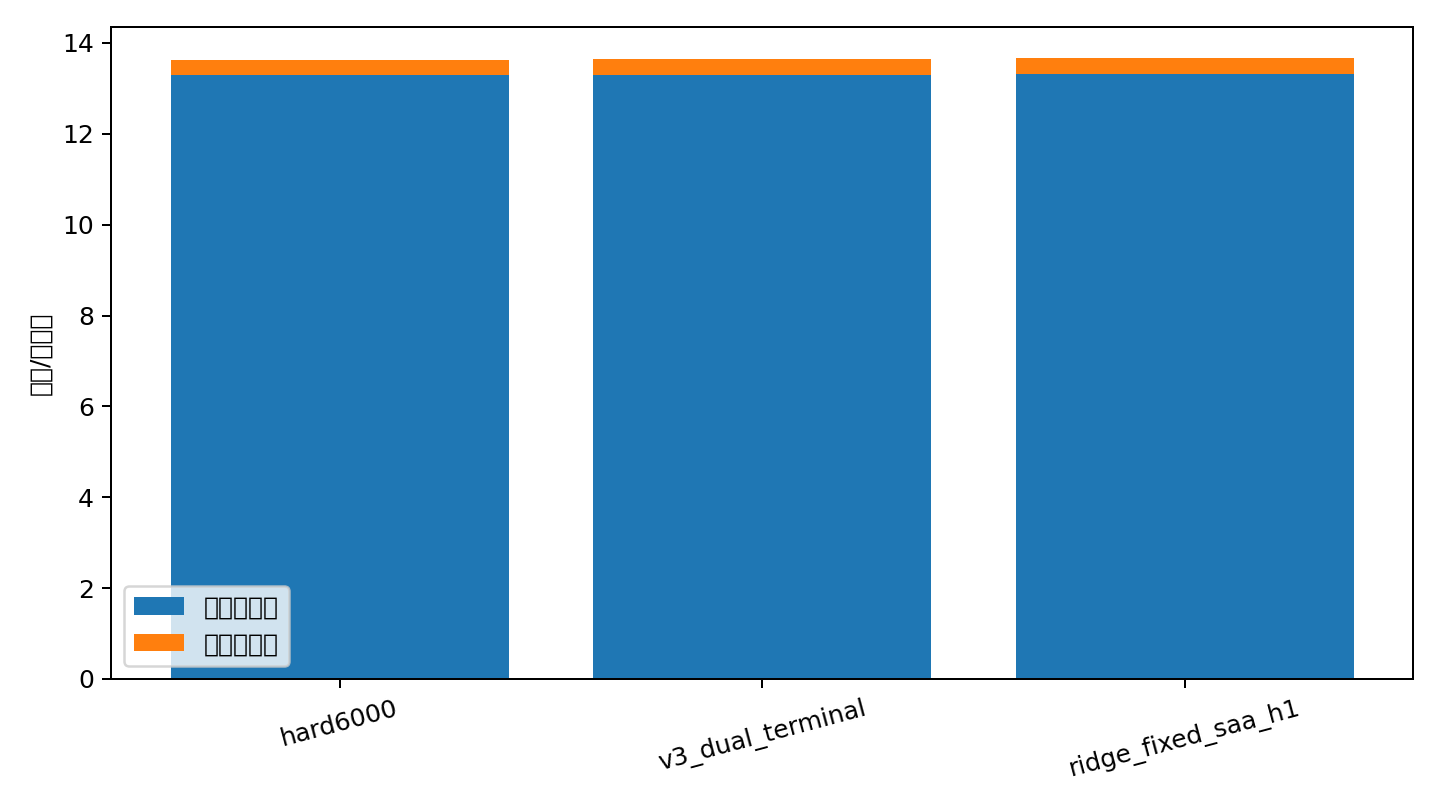

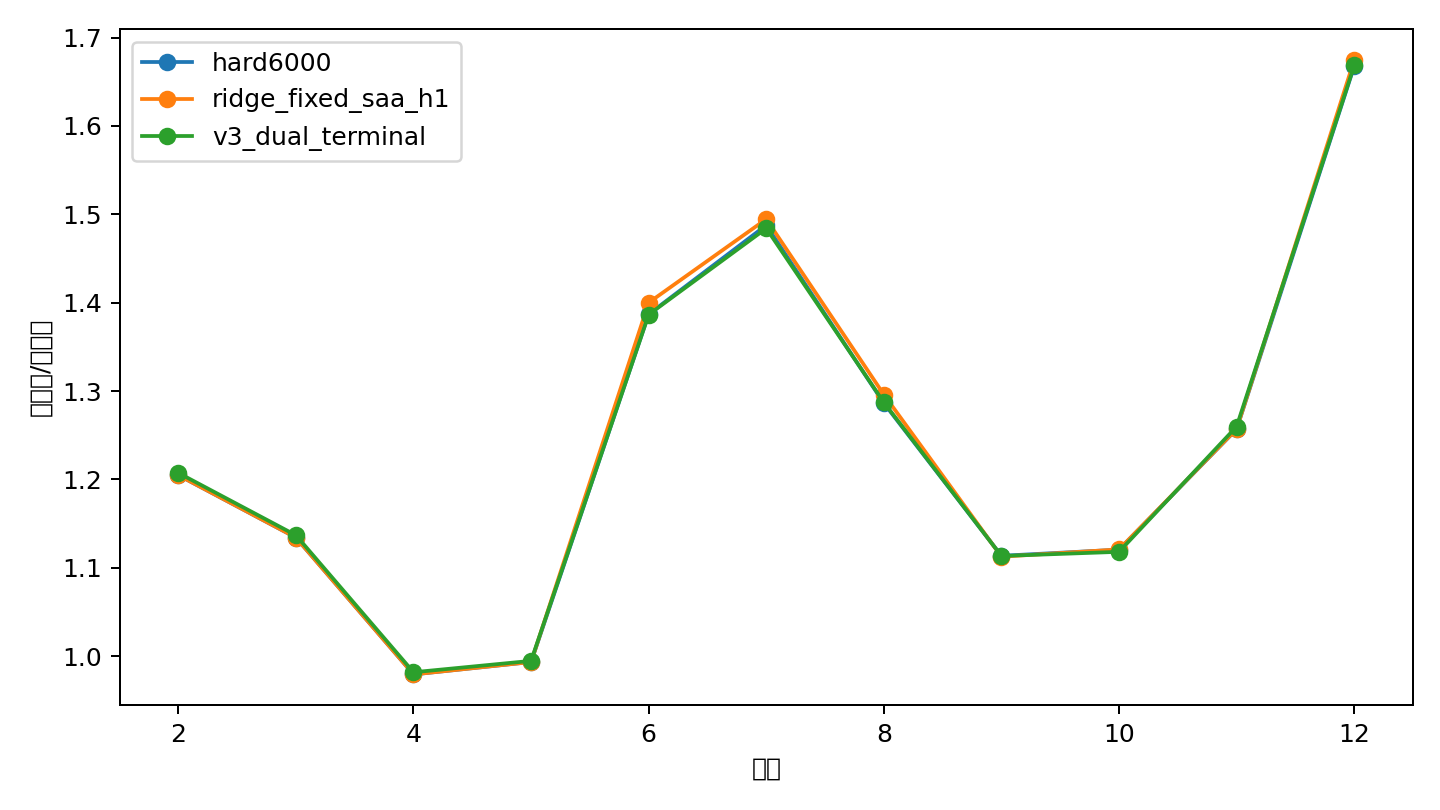

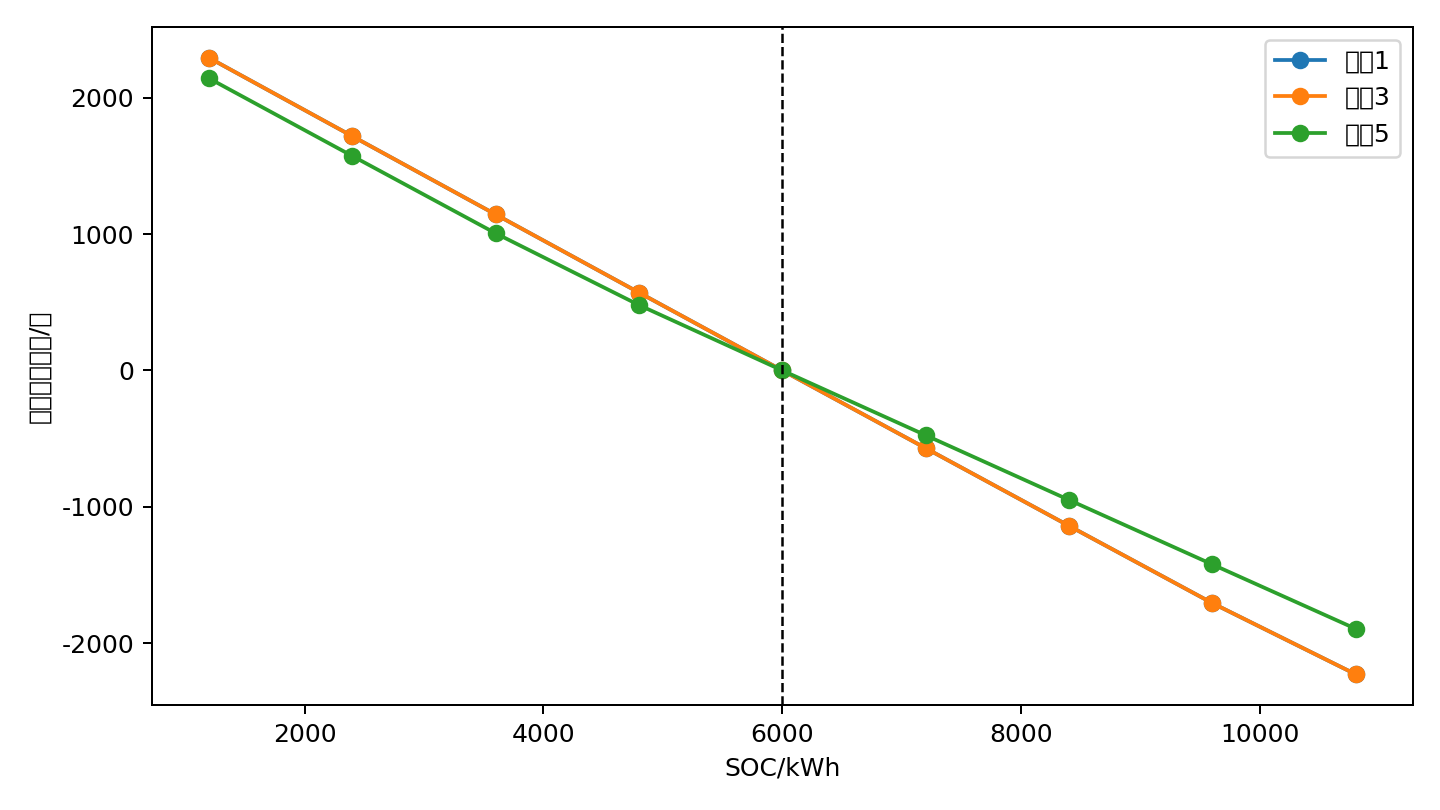

In [7]:
for f in ['01_cost_comparison.png','02_monthly_stability.png','03_terminal_value.png']:
    display(Image(filename=str(FIG/f)))

## 14. 约束、因果性与运行清单

In [8]:
verification=json.loads((OUT/'verification.json').read_text());display(pd.DataFrame(verification['tests']))
manifest=json.loads((OUT/'run_manifest.json').read_text());print(json.dumps(manifest,ensure_ascii=False,indent=2))
assert verification['all_pass'] and manifest['complete']

,test,value,tolerance,passed
0,causality,0.000000e+00,0.000000e+00,True
1,balance,1.705303e-13,1.000000e-07,True
2,soc_recursion,9.094947e-13,1.000000e-07,True
3,lp_eq,8.185452e-11,1.000000e-05,True
4,lp_ineq,6.991741e-12,1.000000e-05,True
5,soc_continuity_hard6000,0.000000e+00,1.000000e-07,True
6,soc_continuity_ridge_fixed_saa_h1,0.000000e+00,1.000000e-07,True
7,soc_continuity_v3_dual_terminal,0.000000e+00,1.000000e-07,True
8,VSS_nonnegative,0.000000e+00,5.000000e-02,True
9,EVPI_nonnegative,0.000000e+00,5.000000e-02,True


{
  "complete": true,
  "resumed_from_raw_checkpoints": true,
  "completed_at": "2026-09-11T17:34:27.953908+00:00",
  "finalization_seconds": 7.460383415222168,
  "notebook": "code/problem2_v3_dual_terminal.ipynb",
  "source_sha256": "8776f516a39e8bb119451f0b3c75d9ff47a2c866f03c8b5d5a45c26be3012567",
  "prediction_sha256": "d6a5e9eee4131debec4e14d5eb15ab1477ab8504f3ef342bcd99d9a3408e9550",
  "daily_hard_terminal": false,
  "remote_hard_terminal": false,
  "all_checks_pass": true
}


## 15. 数据驱动结论

以下文字由本次运行结果自动生成，不预写“新模型更优”。只有开发期改善、Bootstrap支持且冻结期不恶化时，才建议替换现有方案。

In [9]:
s=summary.set_index(['policy','period'])
new=s.loc[('v3_dual_terminal','full334')];base=s.loc[('ridge_fixed_saa_h1','full334')]
dev=s.loc[('v3_dual_terminal','development153')].adjusted_total_cost-s.loc[('ridge_fixed_saa_h1','development153')].adjusted_total_cost
hold=s.loc[('v3_dual_terminal','frozen61')].adjusted_total_cost-s.loc[('ridge_fixed_saa_h1','frozen61')].adjusted_total_cost
b=pd.read_csv(OUT/'bootstrap.csv');ci=b[(b.reference=='ridge_fixed_saa_h1')&(b.period=='full334')].iloc[0]
recommend=(dev<0 and hold<=0 and ci.ci_low95>0)
display(Markdown(f"""全年新模型调整后费用为 **{new.adjusted_total_cost:,.2f} 元**，现有 Ridge 基线为 **{base.adjusted_total_cost:,.2f} 元**。开发期费用差（新−旧）为 **{dev:,.2f} 元**，冻结期为 **{hold:,.2f} 元**；相对旧模型的日节省95%区间为 **[{ci.ci_low95:,.2f}, {ci.ci_high95:,.2f}] 元/日**。据预先声明规则，**{'建议替换' if recommend else '暂不建议替换'}**。"""))

全年新模型调整后费用为 **13,637,013.98 元**，现有 Ridge 基线为 **13,667,408.00 元**。开发期费用差（新−旧）为 **-33,721.72 元**，冻结期为 **-4,602.01 元**；相对旧模型的日节省95%区间为 **[-5.98, 186.68] 元/日**。据预先声明规则，**暂不建议替换**。